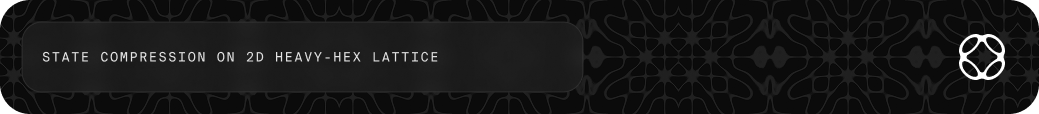

This notebook demonstrates the application of **State Compression** to a quantum simulation problem on the heavy-hex lattice (IBM Heron R3 device with 156 qubits).
We concentrate on a Floquet circuit known to be non-ergodic and hence expected to be highly compressible.

**Why 2D State Compression of Floquet circuits?**

- **Modern device connectivity:** Modern IBM quantum devices have either heavy-hex or square topology. It is important to use this connectivity structure directly in the circuit compression.
- **Non-ergodic dynamics:** Floquet circuits in the non-ergodic regime have slowly spreading entanglement, making them highly compressible using Haiqu's state compression algorithm.
- **Large-scale hardware:** The circuit runs on IBM's 156-qubit Heron R3 heavy-hex device, demonstrating practical utility at scale.

**What does this notebook demonstrate?**

- Haiqu's `state_compression_2d()` achieves up to ~85% CNOT reduction on 10–20 Floquet layer circuits while maintaining high fidelity.
- Magnetization observables from compressed QPU circuits closely match classical tensor network simulations, validating the compression quality.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the notebook

Import the necessary libraries, connect to the Haiqu backend, and initialize the experiment.

In [1]:
# Import helper libraries
import json
import numpy as np

# Connect to the Haiqu backend. Replace with your access key and URL if running outside the Haiqu Lab environment.
from haiqu.sdk import haiqu

# ---- Experiment settings ----
SHOTS = 1024
DEVICE_ID = "ibm_boston"   # Change to your target device, but note that circuit generation is written for devices with Heron R2 and R3 connectivity
RUN_ON_HARDWARE = False    # Set to True to run on real hardware

# Device credentials — fill in to execute on quantum hardware,
# leave empty to load cached results.
options = {
    "ibm_quantum_token": "YOUR_IBM_QUANTUM_API_KEY",          # Replace with your IBM Quantum API key
    "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE_ID",   # Replace with your IBM Quantum instance ID
}

haiqu.login()
haiqu.init("Compression on heavy hex lattice tutorial")

if RUN_ON_HARDWARE:
    print(f"Executing on {DEVICE_ID}")
else:
    print("Loading existing results from cache")

Loading existing results from cache


## 1. Preparing the evolution circuits

First build the Floquet circuit on the heavy-hex lattice. One Floquet layer consists of CZ gates, Ry gates parametrized by angle $\theta $ , and phase gates with random angles. The circuit is initialized in an antiferromagnetic state and evolved through several identical Floquet layers.

For $\theta = 0$ the dynamics is non-ergodic, while for large $\theta$ it is strongly ergodic. For the 1D model a clear transition occurs near $\theta \approx 0.16\pi$; for the 2D model the transition point is less established, but slow dynamics at small $\theta$ still makes such circuits highly compressible.

We define the circuits on all of the 156 qubits of Heron R2 or R3 devices, except for the explicitly excluded qubits with large errors. 

For the detailed definition and discussion of these Floquet circuits see:

**Reference:** O. Shtanko, D. S. Wang, H. Zhang, N. Harle, A. Seif, R. Movassagh, Z. Minev, *Uncovering Local Integrability in Quantum Many-Body Dynamics*, Nature Communications **16**, 2552 (2025). [arXiv:2307.07552](https://arxiv.org/abs/2307.07552)

> **Note:** IBM devices may have "defected" qubits with large gate or measurement errors. The Floquet circuits are defined to exclude these qubits. For the `ibm_boston` device, qubits with indices 46, 85, 116, and 146 are removed. These qubits had large errors at the moment of circuit executions, but they may change in the future.

## Select the backend and circuit parameters

The target device is the IBM Heron R3 heavy-hex device `ibm_boston`.

In [2]:
from utils import create_floquet_circuit

device = haiqu.get_device(DEVICE_ID)
# other circuit parameters:
theta = 0.1*np.pi    # non-ergodic regime
seed = 42
num_floquet_layers = 10

# creating the circuit:
circuits = create_floquet_circuit(theta, [num_floquet_layers,], seed, defected_qubits=[46, 85, 116, 146])
qc = circuits[0]

## 2. Compressing the circuit

Apply `haiqu.state_compression_2d()` to the 10-layer Floquet circuit. The compressor targets the IBM Heron R3 noise profile and uses high compression level.

In [3]:
from utils import print_compression_info

fine_tuning = "disabled" # if to additionally fine-tune the compressed circuit (can be slow)
job_h = haiqu.state_compression_2d(circuit=qc, fine_tuning=fine_tuning, device=device, compression_level="high")
circuit = job_h.result()
print_compression_info(job_h.info)

Compression results
  Status       : Compressed
  Quality      : 0.9353
  Compression  : 80.00%


The circuit was compressed nearly 5× in terms of CNOT count (≈80% reduction) while maintaining high compression quality. Note that the precise compression level may slightly change.

## 3. Comparing the circuits on QPU

Build and compress circuits with 2–20 Floquet layers. We use all 2-20 Floquet layers for comparison plots later. Feel free to modify the number of layers to get Quality vs Compression plot, but if you want to reproduce the hardware results, circuits for all 2-20 layers are needed because the classical results are precomputed.

In [4]:
layers = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]     # layers of the Floquet circuit
circuits = create_floquet_circuit(theta, layers, seed, defected_qubits=[46, 85, 116, 146])

> **Note:** The compression steps below may take several minutes per circuit.

In [5]:
compression_jobs = []
fine_tuning = "disabled"
for qc in circuits:
    job_h = haiqu.state_compression_2d(circuit=qc, fine_tuning=fine_tuning, device=device, compression_level="high")
    compression_jobs.append(job_h)

compressed_circuits = []
qualities = []
compressions = []
for l, job_h in enumerate(compression_jobs):
    layer = layers[l]
    compressed_circuit = job_h.result()
    compressed_circuits.append(compressed_circuit)
    print_compression_info(job_h.info, label=f"Layer {layer}")
    qualities.append(job_h.info.get('compression_quality', 0))
    compressions.append(job_h.info.get('compression_percent', 0))

Layer 2
  Status       : Compressed
  Quality      : 0.9932
  Compression  : 5.39%
Layer 4
  Status       : Compressed
  Quality      : 0.9792
  Compression  : 50.00%
Layer 6
  Status       : Compressed
  Quality      : 0.9659
  Compression  : 66.87%
Layer 8
  Status       : Compressed
  Quality      : 0.9480
  Compression  : 75.00%
Layer 10
  Status       : Compressed
  Quality      : 0.9353
  Compression  : 80.00%
Layer 12
  Status       : Compressed
  Quality      : 0.9225
  Compression  : 83.33%
Layer 14
  Status       : Compressed
  Quality      : 0.9147
  Compression  : 85.71%
Layer 16
  Status       : Compressed
  Quality      : 0.9118
  Compression  : 79.45%
Layer 18
  Status       : Compressed
  Quality      : 0.9117
  Compression  : 70.63%
Layer 20
  Status       : Compressed
  Quality      : 0.9117
  Compression  : 63.56%


## Quality vs. compression

Visualize the trade-off between compression quality and compression ratio across all Floquet layer counts. Each point is annotated with the number of Floquet layers.

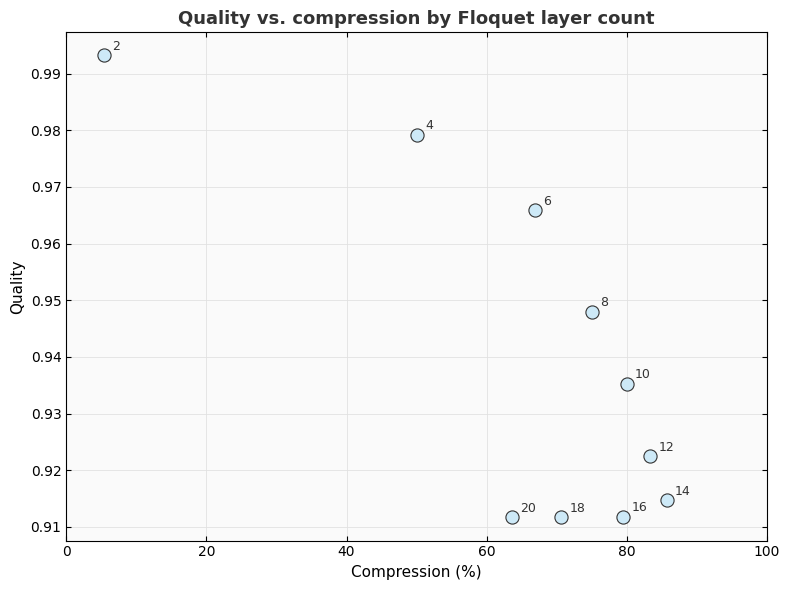

"Logged object to the experiment 'Compression on heavy hex lattice tutorial'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

In [6]:
from utils import plot_quality_vs_compression

haiqu.log(plot_quality_vs_compression(layers, qualities, compressions), name="quality_vs_compression")

The quality decreases with the number of layers, as it is harder to compress efficiently deep circuits. The compression ratio at the same time increases. Eventually, the circuit becomes so deep and complicated, that only its part is compressed. Then the quality becomes constant and the compression ratio starts to worthen.

## Run circuits on QPU

Submit both original and compressed circuits to QPU via `haiqu.run()` and save the shot counts to JSON. When `RUN_ON_HARDWARE = False`, pre-saved results are loaded from the data directory instead.

> **Note:** QPU experiments were conducted on March 30th, 2026. Your mileage may vary.

In [7]:
# Pre-computed results (never overwritten)
CACHED_COUNTS_ORIGINAL   = 'compression_2d_counts_and_classical_data/counts_floquet_original.json'
CACHED_COUNTS_COMPRESSED = 'compression_2d_counts_and_classical_data/counts_floquet_compressed.json'

# Output files for new hardware runs
COUNTS_FILE_ORIGINAL   = 'compression_2d_counts_and_classical_data/original_counts_new.json'
COUNTS_FILE_COMPRESSED = 'compression_2d_counts_and_classical_data/compressed_counts_new.json'

if RUN_ON_HARDWARE:
    job_original = haiqu.run(
        circuits,
        shots=SHOTS,
        device_id=DEVICE_ID,
        options=options,
    )
    job_compressed = haiqu.run(
        compressed_circuits,
        shots=SHOTS,
        device_id=DEVICE_ID,
        options=options,
    )
    print(f"Original job ID:   {job_original.id}")
    print(f"Compressed job ID: {job_compressed.id}")

    counts_original = job_original.result()
    counts_compressed = job_compressed.result()

    with open(COUNTS_FILE_ORIGINAL, 'w') as f:
        json.dump(counts_original, f)
    with open(COUNTS_FILE_COMPRESSED, 'w') as f:
        json.dump(counts_compressed, f)
    print(f"Results saved to {COUNTS_FILE_ORIGINAL} and {COUNTS_FILE_COMPRESSED}")
else:
    with open(CACHED_COUNTS_ORIGINAL) as f:
        counts_original = json.load(f)
    with open(CACHED_COUNTS_COMPRESSED) as f:
        counts_compressed = json.load(f)
    print(f"Loaded original results from {CACHED_COUNTS_ORIGINAL} ({len(counts_original)} circuits)")
    print(f"Loaded compressed results from {CACHED_COUNTS_COMPRESSED} ({len(counts_compressed)} circuits)")

Loaded original results from compression_2d_counts_and_classical_data/counts_floquet_original.json (10 circuits)
Loaded compressed results from compression_2d_counts_and_classical_data/counts_floquet_compressed.json (10 circuits)


## Learn from results

Compare the magnetization curves of original and compressed QPU circuits against classical tensor network simulation to validate the compression quality across all Floquet layer counts.

## Load classical simulation data

Load magnetization data computed via tensor network simulation for the uncompressed circuits. This serves as the noiseless reference for comparison.

The data was computed in quimb package with the framework proposed in Reference:

**Reference:** J. Tindall, M. Fishman, M. Stoudenmire, D. Sels, *Efficient tensor network simulation of IBM's Eagle kicked Ising experiment*, PRX Quantum **5**, 010308 (2024). [arXiv:2306.14887](https://arxiv.org/abs/2306.14887)

In [ ]:
layers = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]     # layers of the Floquet circuit
magnetizations_original_classical = np.load("compression_2d_counts_and_classical_data/magnetizations_original_classical.npy")

## Compute magnetizations from QPU shots

Calculate the average magnetization from the bitstring shot distributions for both original and compressed circuits.

In [9]:
from utils import compute_magnetizations

magnetizations_original_qpu, magnetizations_compressed_qpu = compute_magnetizations(counts_original, counts_compressed)

## Plot results

Compare magnetization as a function of Floquet layers across classical simulation, original QPU circuits, and compressed QPU circuits.

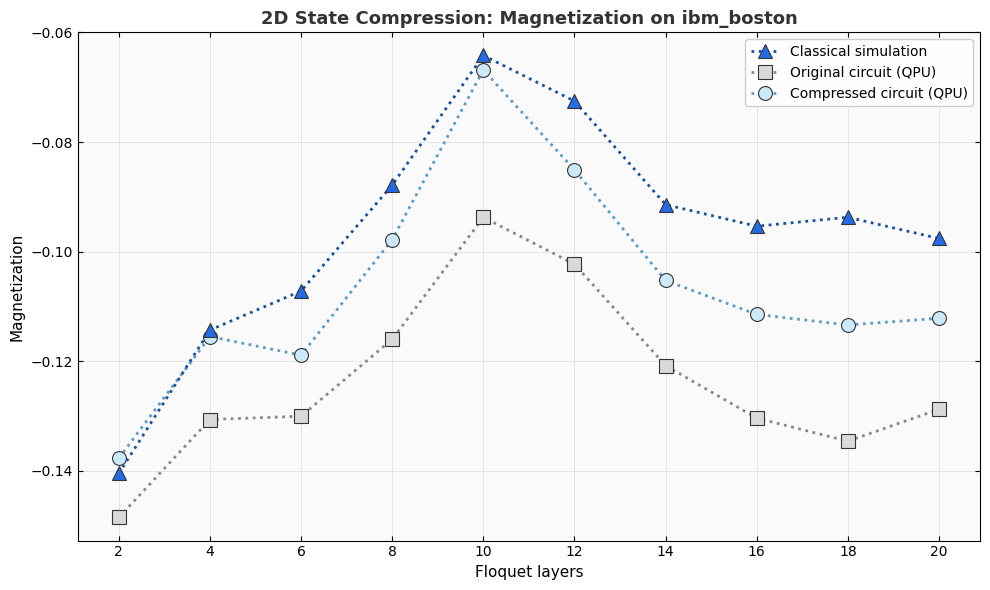

"Logged object to the experiment 'Compression on heavy hex lattice tutorial'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

In [10]:
from utils import plot_magnetizations

haiqu.log(plot_magnetizations(layers, magnetizations_original_classical, magnetizations_original_qpu, magnetizations_compressed_qpu, device_id=DEVICE_ID), name="magnetization")

Compressed circuits generally have magnetizations that are closer to those of classical simulations than uncompressed circuits, especially for a number of layers smaller than 16. At 16 layers, the compression ratio of the compressed circuits begins to worsen, and the compressed circuits become deeper. As a result, the difference between classical simulations and compressed circuits shots increases.

## Conclusions

- Haiqu's 2D state compression achieves up to **85% CNOT reduction** on Floquet circuits with 10–14 layers while maintaining compression quality above **91%**.

- Magnetization observables from compressed QPU circuits closely match classical tensor network simulations, validating that the compressed circuits faithfully represent the original quantum dynamics.

- For very deep circuits (16+ layers), the classically simulatable part of the circuit shrinks, the compression ratio decreases, and the advantage over running uncompressed circuits diminishes.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

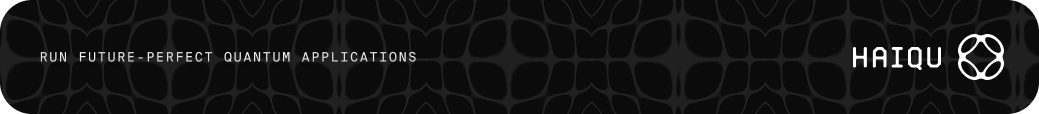